In [2]:
import numpy as np
from scipy import optimize

from baseline import baseline_nonlinear, baseline_loe, baseline_formulas as bf
from plotting import plots_baseline

# Main calibration

In [3]:
alpha = 1/9
eta = 1.15
gamma = 1.5
sigma = 1.79

In [4]:
dtau = 0.1  # 10% tariff is main experiment

# Unilateral case: figure 3 and numerical results

Numerical values for 10% tariff (reported in text - note slight changes from latest draft, to be updated):

In [25]:
print(f'GDP change: {dtau*bf.GDP_unilateral(alpha, eta, gamma, sigma):.2%}')
print(f'TB change (relative to GDP): {dtau*alpha/(1-alpha)*bf.TB_unilateral(alpha, eta, gamma, sigma):.1%}')
print(f'TB change (relative to imports): {dtau*bf.TB_unilateral(alpha, eta, gamma, sigma):.1%}')

GDP change: -0.68%
TB change (relative to GDP): 1.5%
TB change (relative to imports): 11.6%


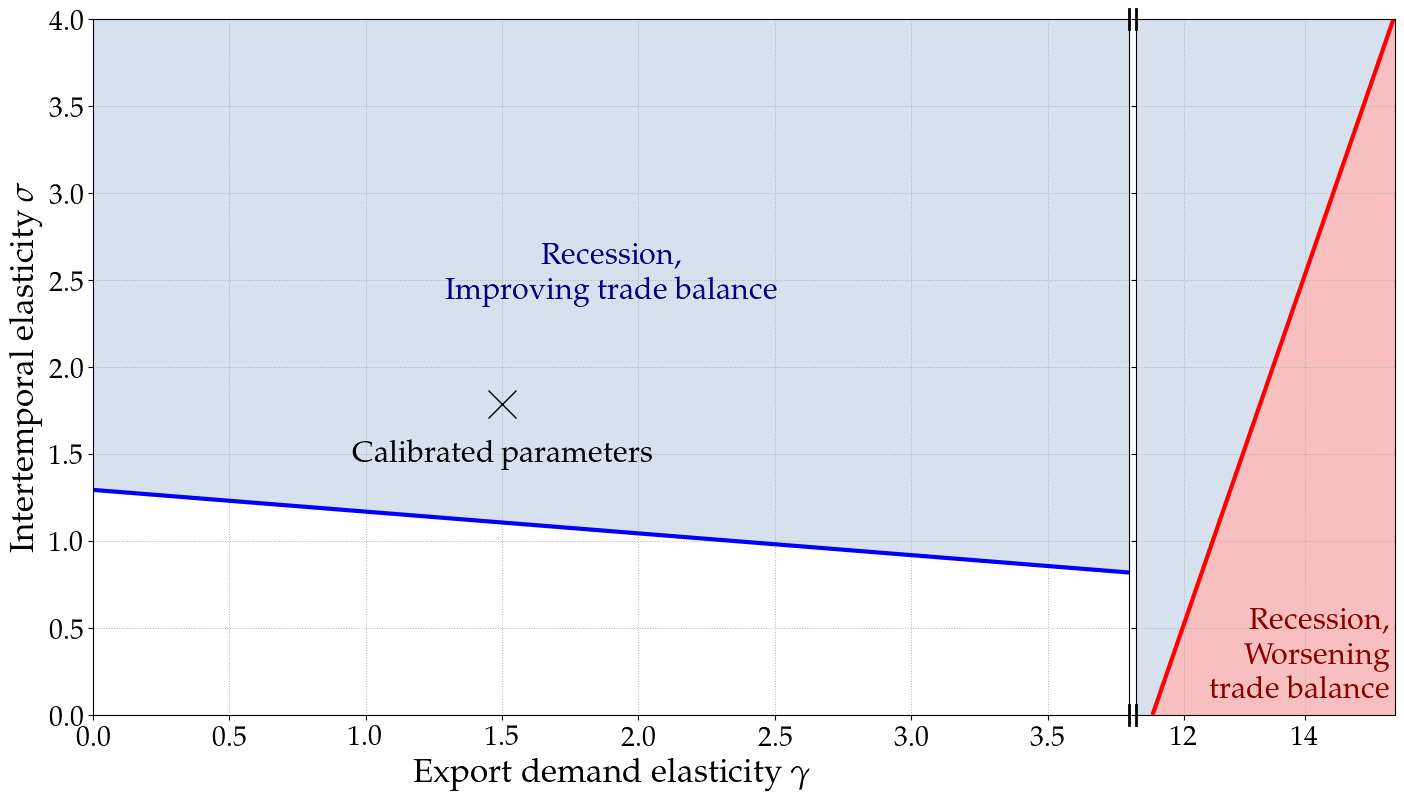

In [6]:
plots_baseline.plot_gamma_sigma_split(
    lambda gamma, sigma: bf.GDP_unilateral(alpha, eta, gamma, sigma),
    lambda gamma, sigma: bf.TB_unilateral(alpha, eta, gamma, sigma),
    xlim_left=(0, 3.8), xlim_right=(11.2, 15.5), ylim=(0, 4),
    calibrated_point=(gamma, sigma), filename='gamma_sigma_unilateral.pdf'
)

### With stabilizing policy (natural rate)

In [29]:
print(f'Rate change: {dtau*bf.rate_unilateral_natural(alpha, eta, gamma, sigma):.2%}')
print(f'TB change (relative to imports): {dtau*bf.TB_unilateral_natural(alpha, eta, gamma, sigma):.1%}')

Rate change: -0.40%
TB change (relative to imports): 11.6%


# Retaliation case: figure 5 and numerical results

In [30]:
print(f'GDP change: {dtau*bf.GDP_retaliation(alpha, eta, gamma, sigma):.1%}')
print(f'TB change (relative to imports): {dtau*bf.TB_retaliation(alpha, eta, gamma, sigma):.1%}')


GDP change: -2.3%
TB change (relative to imports): -1.7%


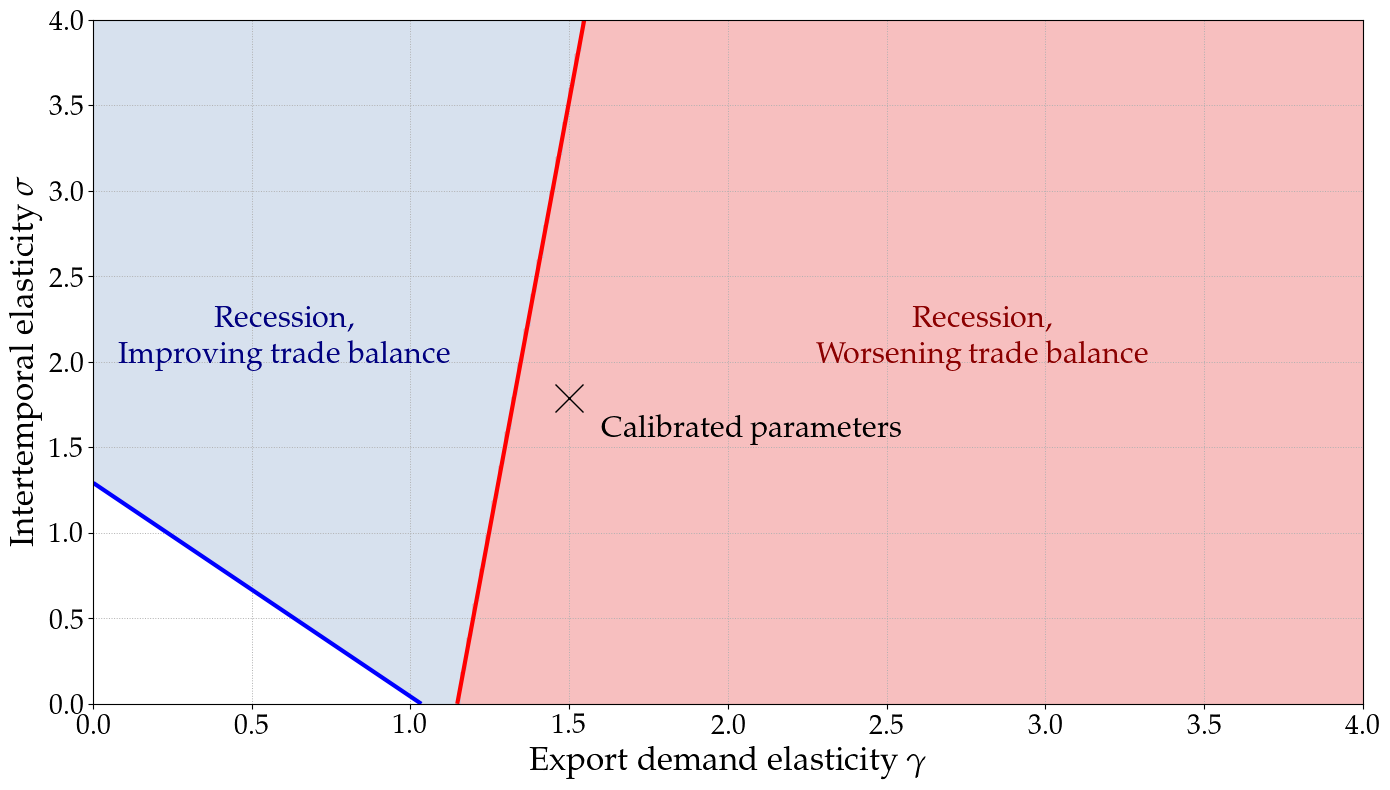

In [9]:
plots_baseline.plot_gamma_sigma_simple(
    lambda gamma, sigma: bf.GDP_retaliation(alpha, eta, gamma, sigma),
    lambda gamma, sigma: bf.TB_retaliation(alpha, eta, gamma, sigma),
    xlim=(0, 4), ylim=(0, 4),
    calibrated_point=(gamma, sigma), filename='gamma_sigma_retaliation.pdf'
)

# Appendix figure 16: Nonlinearities with large tariffs

First figures 16ac:

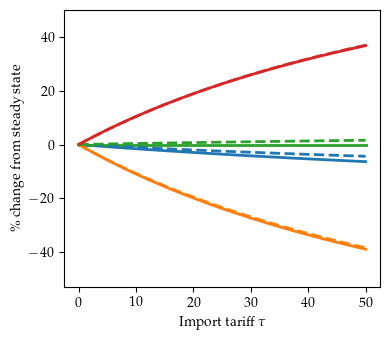

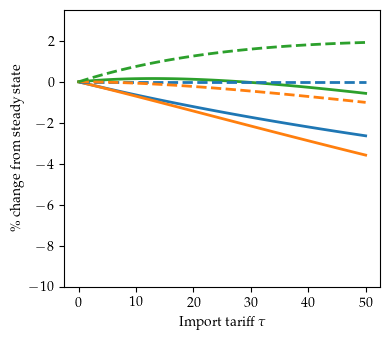

In [10]:
taus = np.linspace(0, 0.5, 100)
results = [baseline_nonlinear.solve_shortrun(tau, alpha, eta, gamma, sigma) for tau in taus]
results_nat = [baseline_nonlinear.solve_shortrun(tau, alpha, eta, gamma, sigma, natural=True) for tau in taus]
baseline_nonlinear.add_chained_GDP(results)
baseline_nonlinear.add_chained_GDP(results_nat)
plots_baseline.plot_nonlinear(results, results_nat, 'nonlinear_unilateral')

Now figures 16bd with retaliation:

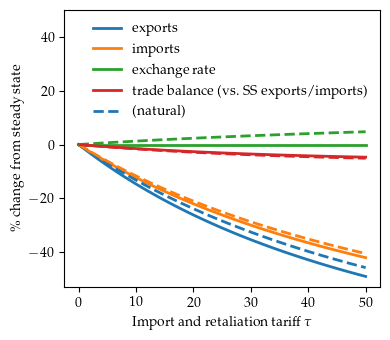

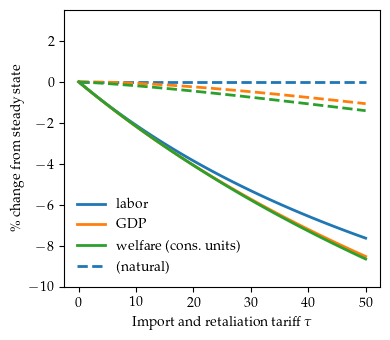

In [11]:
results = [baseline_nonlinear.solve_shortrun(tau, alpha, eta, gamma, sigma, retaliation=True) for tau in taus]
results_nat = [baseline_nonlinear.solve_shortrun(tau, alpha, eta, gamma, sigma, natural=True, retaliation=True) for tau in taus]
baseline_nonlinear.add_chained_GDP(results)
baseline_nonlinear.add_chained_GDP(results_nat)
plots_baseline.plot_nonlinear(results, results_nat, 'nonlinear_retaliation', retaliation=True)

# Figure 6: large open economy with retaliation

In [12]:
lambs = np.linspace(0, 0.5, 100)
results = [baseline_loe.solve_loe(dtau, lamb, alpha, eta, gamma, sigma, retaliation=True) for lamb in lambs]

series = zip(*[(r.dlogGDP, r.dlogGDP_star, r.dlogX, r.dlogM, r.dTB_Tr) for r in results])
dlogGDP, dlogGDP_star, dlogX, dlogM, dTB_Tr = [np.array(s) for s in series]

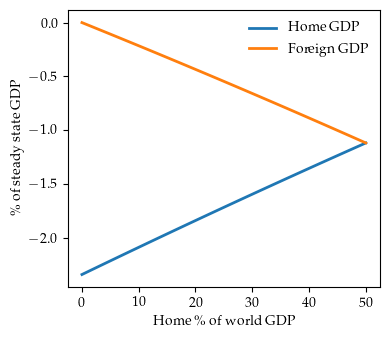

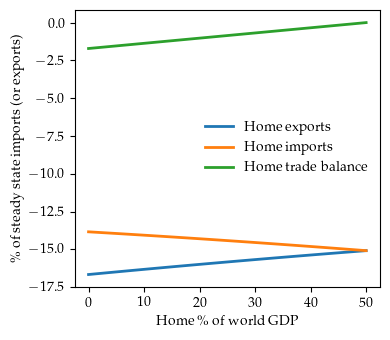

In [13]:
plots_baseline.plot_large_open_economy(lambs, dlogGDP, dlogGDP_star, dlogX, dlogM, dTB_Tr, 'loe')

# Figures 7 and 17: permanent tariff surprise

Obtain long-run response to tariff given higher long-run elasticities:

In [14]:
gamma_LR = (8/3)*gamma
eta_LR = (8/3)*eta
taus = np.linspace(0, 0.5, 100)

In [15]:
# solve for long run first, then feed into short run
# unilateral case
results_LR = [baseline_nonlinear.solve_longrun(tau, alpha, eta_LR, gamma_LR) for tau in taus]
results_SR = [baseline_nonlinear.solve_shortrun_inner(tau, 0, 0, 1, alpha, eta, gamma, sigma,
                                                    E_LR=r.E, P_LR=r.P, C_LR=r.C) for tau, r in zip(taus, results_LR)]
baseline_nonlinear.add_chained_GDP(results_SR)
baseline_nonlinear.add_chained_GDP(results_LR)
N_unilateral = np.array([r.N for r in results_SR])
GDP_SR_unilateral = np.array([r.GDP for r in results_SR])
GDP_LR_unilateral = np.array([r.GDP for r in results_LR])

# retaliation case
results_LR = [baseline_nonlinear.solve_longrun(tau, alpha, eta_LR, gamma_LR, retaliation=True) for tau in taus]
results_SR = [baseline_nonlinear.solve_shortrun_inner(tau, tau, 0, 1, alpha, eta, gamma, sigma,
                                                    E_LR=r.E, P_LR=r.P, C_LR=r.C) for tau, r in zip(taus, results_LR)]
baseline_nonlinear.add_chained_GDP(results_SR)
baseline_nonlinear.add_chained_GDP(results_LR)
N_retaliation = np.array([r.N for r in results_SR])
GDP_SR_retaliation = np.array([r.GDP for r in results_SR])
GDP_LR_retaliation = np.array([r.GDP for r in results_LR])

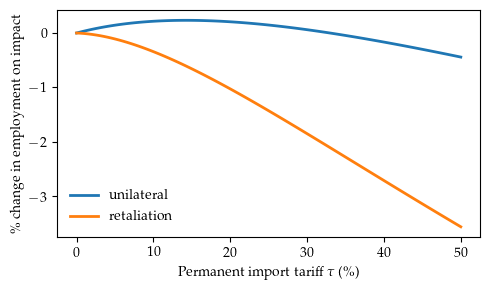

In [16]:
plots_baseline.plot_longrun_nonlinear(taus, N_unilateral, N_retaliation, 'nonlinear_longrun.pdf')

For appendix figure 17, also add short-run and long-run GDP to the plot.

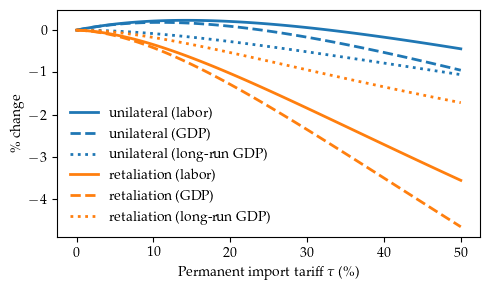

In [17]:
plots_baseline.plot_longrun_nonlinear_withGDP(taus, N_unilateral, N_retaliation, GDP_SR_unilateral, GDP_SR_retaliation,
                                                GDP_LR_unilateral, GDP_LR_retaliation, 'nonlinear_longrun_withGDP.pdf')

# Figure 8: first-order welfare losses

In [18]:
gammas = np.linspace(0, 4, 500)
sigmas_unilateral = np.array([optimize.root_scalar(lambda sigma: 
                        bf.Welfare(alpha, eta, gam, sigma)[0], method='brentq', bracket=(-50, 100)).root for gam in gammas])
sigmas_retaliation = np.array([optimize.root_scalar(lambda sigma:
                        bf.Welfare(alpha, eta, gam, sigma, retaliation=True)[0], method='brentq', bracket=(-50, 100)).root for gam in gammas])

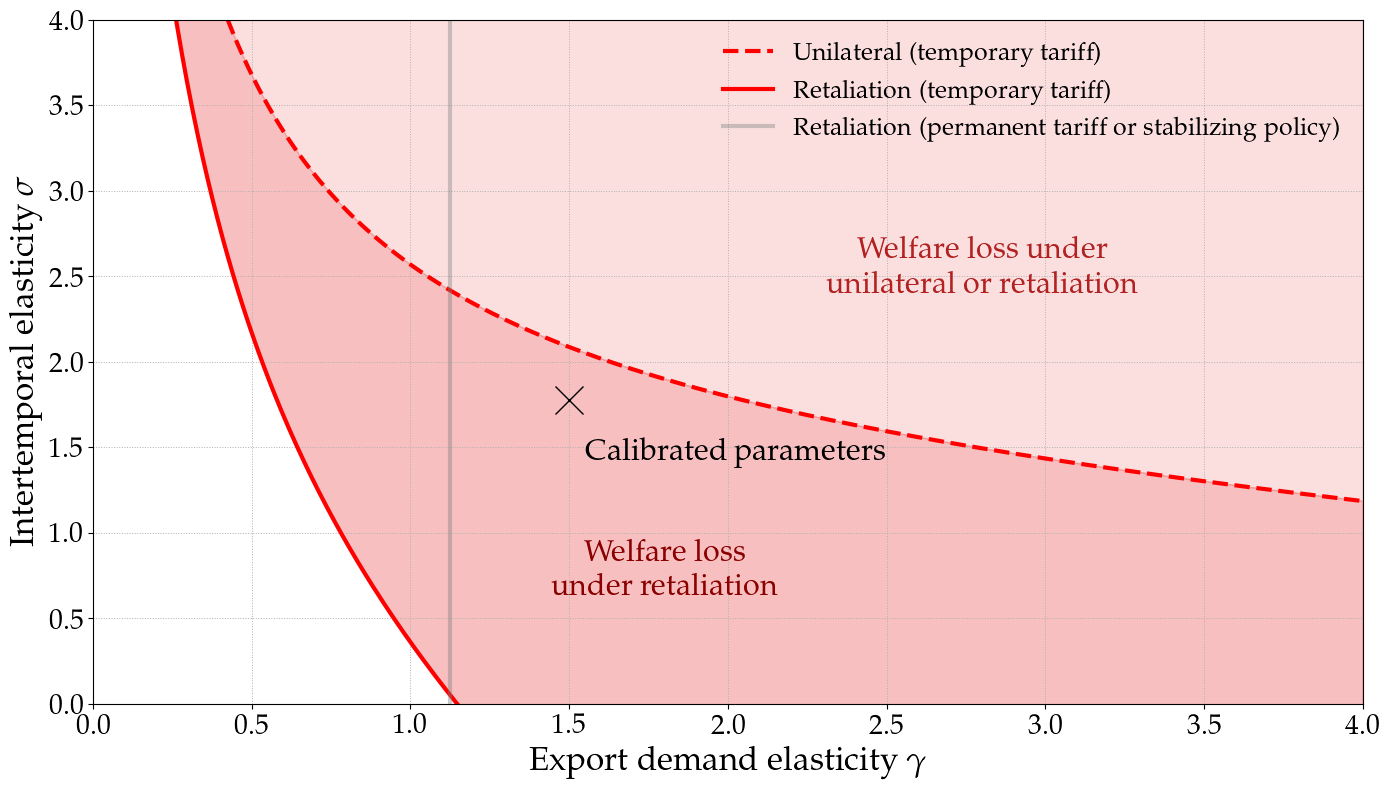

In [19]:
plots_baseline.plot_gamma_sigma_welfare(gammas, sigmas_unilateral, sigmas_retaliation, alpha, 'gamma_sigma_welfare.pdf')

# Figures 9 and 18: nonlinear welfare effects from tariff
First our figure 9 in the main text:

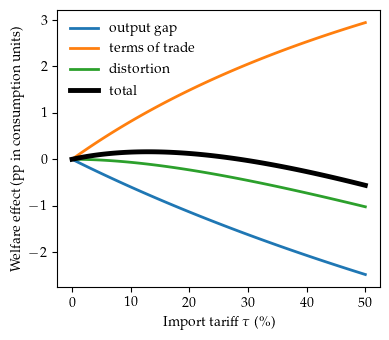

In [20]:
taus, (total, gap, tot, distortion) = baseline_nonlinear.welfare_decomposition(0.5, alpha, eta, gamma, sigma)
plots_baseline.plot_nonlinear_welfare(taus, gap, tot, distortion, 'nonlinear_welfare_unilateral.pdf', legend=True)

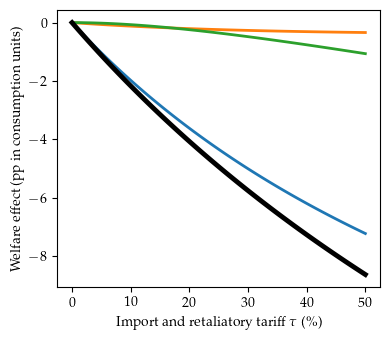

In [21]:
taus, (total, gap, tot, distortion) = baseline_nonlinear.welfare_decomposition(0.5, alpha, eta, gamma, sigma, retaliation=True)
plots_baseline.plot_nonlinear_welfare(taus, gap, tot, distortion, 'nonlinear_welfare_retaliation.pdf', retaliation=True)

Then appendix figure 18 for long-run elasticity case:

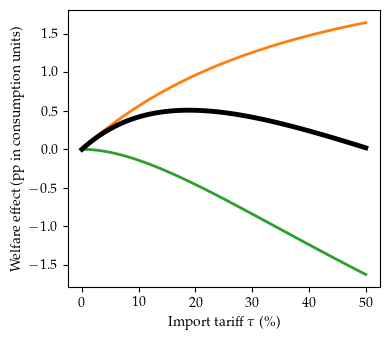

In [22]:
taus, (total, gap, tot, distortion) = baseline_nonlinear.welfare_decomposition(0.5, alpha, eta*(8/3), gamma*(8/3), sigma)
plots_baseline.plot_nonlinear_welfare(taus, gap, tot, distortion, 'nonlinear_welfare_unilateral_alt.pdf')

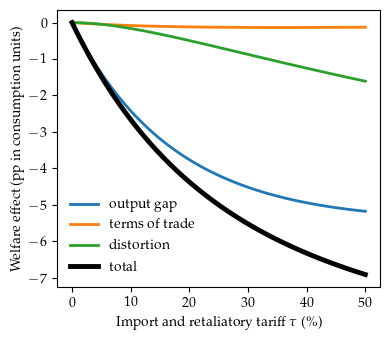

In [23]:
taus, (total, gap, tot, distortion) = baseline_nonlinear.welfare_decomposition(0.5, alpha, eta*(8/3), gamma*(8/3), sigma, retaliation=True)
plots_baseline.plot_nonlinear_welfare(taus, gap, tot, distortion, 'nonlinear_welfare_retaliation_alt.pdf', retaliation=True, legend=True)